In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load cleaned dataset
df = pd.read_csv("cleaned_stock_prices.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Create folder to save images
os.makedirs("visualizations", exist_ok=True)

df.head()

,symbol,date,open,high,low,close,volume
0,A,2014-01-02,57.10,57.100,56.15,56.21,1916160
1,A,2014-01-03,56.39,57.345,56.26,56.92,1866651
2,A,2014-01-06,57.40,57.700,56.56,56.64,1777472
3,A,2014-01-07,56.95,57.630,56.93,57.45,1463208
4,A,2014-01-08,57.33,58.540,57.17,58.39,2659468


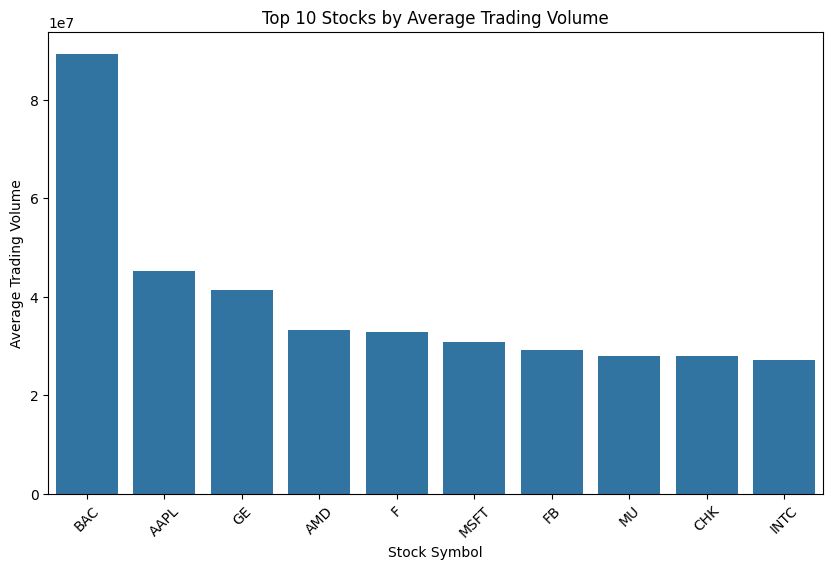

In [2]:
# Get top 10 stocks by average trading volume
top_volume = (
    df.groupby("symbol")["volume"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_volume, x="symbol", y="volume")

plt.title("Top 10 Stocks by Average Trading Volume")
plt.xlabel("Stock Symbol")
plt.ylabel("Average Trading Volume")
plt.xticks(rotation=45)

plt.savefig("visualizations/top_10_stocks_by_volume.png", bbox_inches="tight")
plt.show()

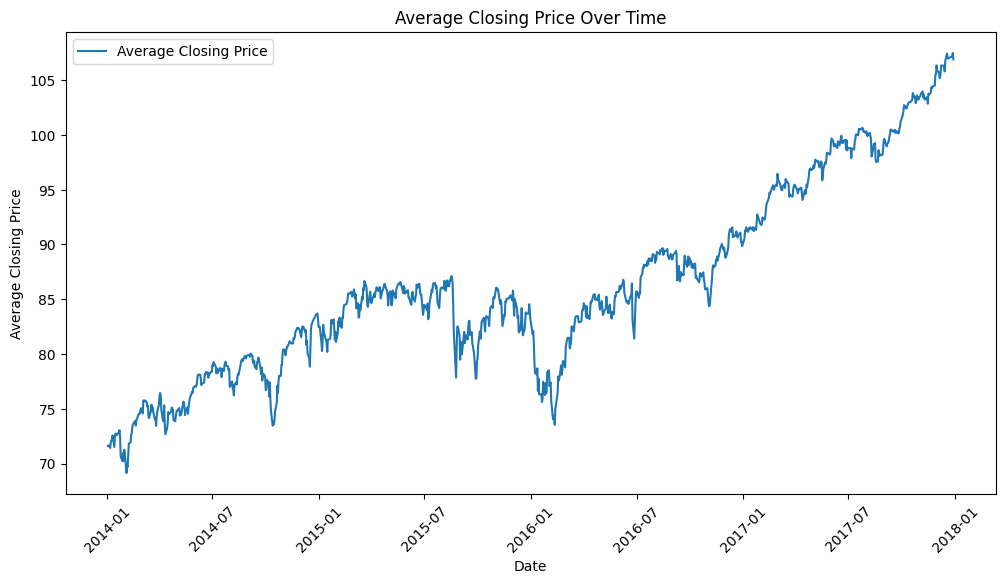

In [3]:
# Calculate average closing price per date
daily_close = df.groupby("date")["close"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_close["date"], daily_close["close"], label="Average Closing Price")

plt.title("Average Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Closing Price")
plt.legend()
plt.xticks(rotation=45)

plt.savefig("visualizations/average_closing_price_over_time.png", bbox_inches="tight")
plt.show()

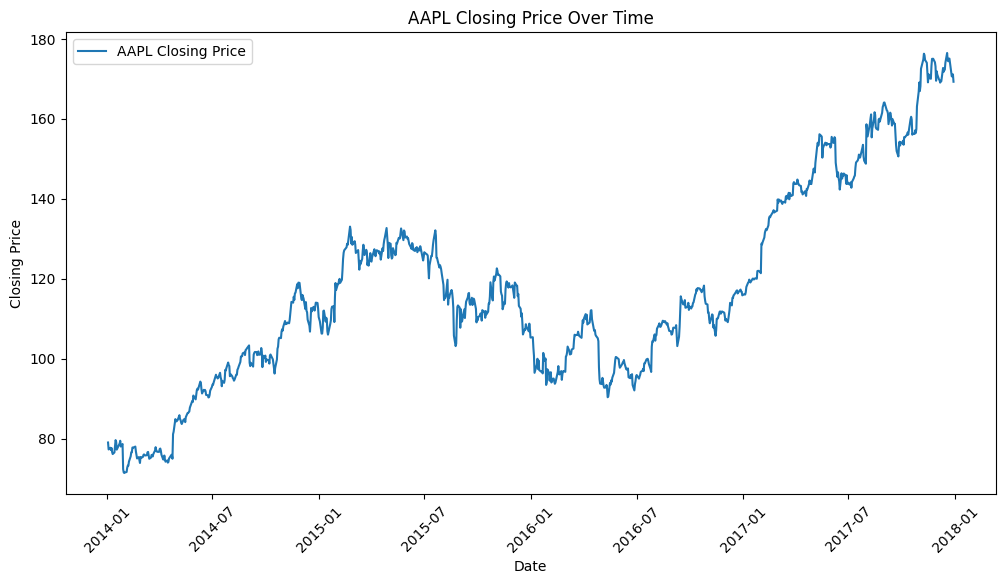

In [4]:
# Select one stock symbol
selected_stock = "AAPL"

# Filter data for selected stock
stock_data = df[df["symbol"] == selected_stock]

plt.figure(figsize=(12, 6))
plt.plot(stock_data["date"], stock_data["close"], label=f"{selected_stock} Closing Price")

plt.title(f"{selected_stock} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)

plt.savefig(f"visualizations/{selected_stock}_closing_price_over_time.png", bbox_inches="tight")
plt.show()

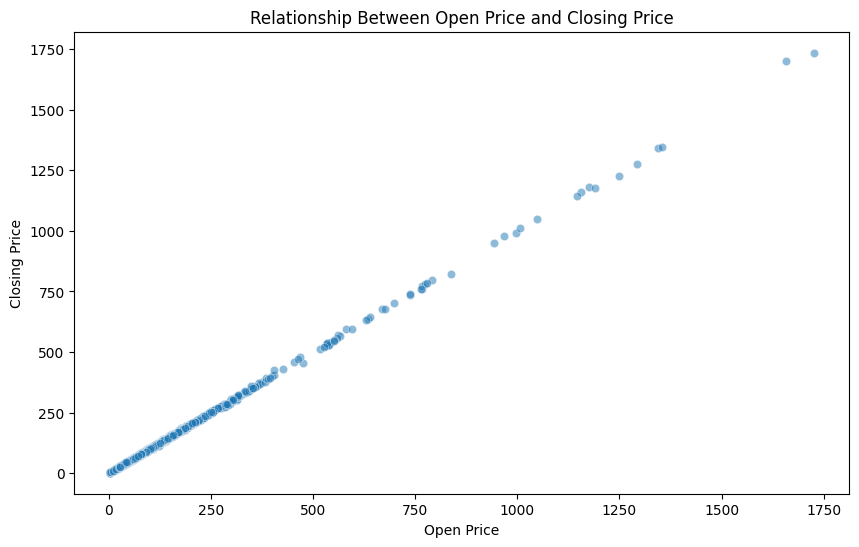

In [5]:
# Use a sample because the dataset is very large
df_sample = df.sample(n=5000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x="open", y="close", alpha=0.5)

plt.title("Relationship Between Open Price and Closing Price")
plt.xlabel("Open Price")
plt.ylabel("Closing Price")

plt.savefig("visualizations/open_vs_close_scatter.png", bbox_inches="tight")
plt.show()

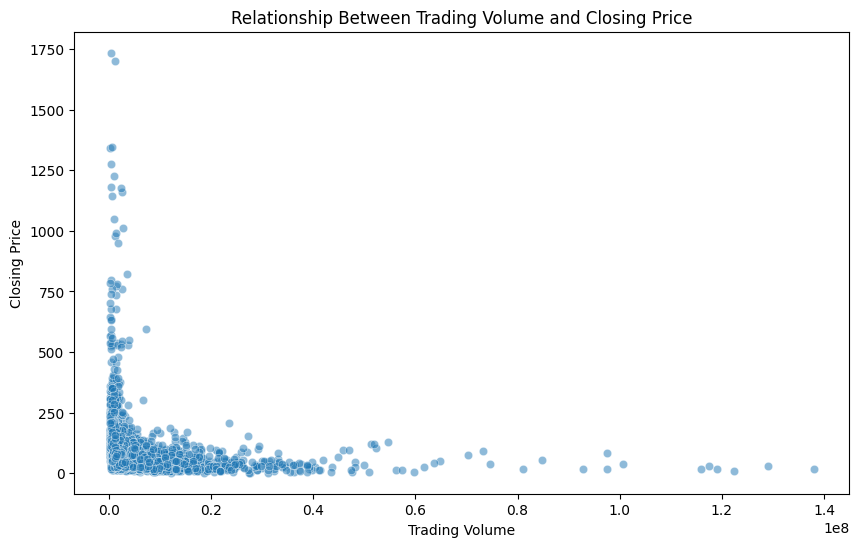

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x="volume", y="close", alpha=0.5)

plt.title("Relationship Between Trading Volume and Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

plt.savefig("visualizations/volume_vs_close_scatter.png", bbox_inches="tight")
plt.show()

In [7]:
os.listdir("visualizations")

['AAPL_closing_price_over_time.png',
 'average_closing_price_over_time.png',
 'open_vs_close_scatter.png',
 'top_10_stocks_by_volume.png',
 'volume_vs_close_scatter.png']

## Task 3: Basic Data Visualization Summary

For Task 3, I created basic visualizations using the cleaned stock prices dataset. A bar plot was used to show the top 10 stocks by average trading volume. Line charts were created to show the average closing price over time and the closing price trend for AAPL. Scatter plots were used to show the relationship between opening price and closing price, as well as trading volume and closing price.

The charts were customized with clear titles, axis labels, and legends where appropriate. Each visualization was exported as a PNG image and saved in the `visualizations` folder for use in reports.